# Gotthard Magnification from Shadow Fringes

This notebook loads the raw Gotthard VLS data for the signal run (58892) and the background run (58893), averages each run over trains, subtracts the background, and estimates the detector magnification from the shadow fringe spacing.

Known geometry: the line spacing on the calibration sheet is 0.68 mm.
Known detector pixel size: 50 um.

The workflow follows the raw-VLS loader pattern used in [inspect_raw_vls.ipynb](inspect_raw_vls.ipynb).

In [6]:
import glob
import os
import sys
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

%matplotlib inline

os.environ.setdefault('FLASH_ENV', 'local')

cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd] + list(cwd.parents):
    if (p / 'analysis' / 'scripts').exists():
        repo_root = p
        break
if repo_root is None:
    raise RuntimeError('Could not locate repository root.')

sys.path.insert(0, str(repo_root / 'analysis' / 'scripts'))

import config as path_config
from data_loading import ExperimentData, load_raw_h5

## Parameters

If the automatic fringe detection is too loose or too strict, adjust `SMOOTH_SIGMA_PIXELS`, `MIN_PEAK_DISTANCE_PIXELS`, or `PROFILE_ROI`.

`TRAIN_LENGTH` and `N_VLS_PIXELS` are inferred from the first raw file for each run so the notebook does not silently truncate the Gotthard stack.

In [7]:
CONFIG = 2
SIGNAL_RUN_NO = 58892
BACKGROUND_RUN_NO = 58893
RAW_DIR = Path(path_config.RAW_H5_DIR)
MAX_FILES = None

GRID_SPACING_MM = 0.68
PIXEL_SIZE_MM = 0.050  # 50 um

SMOOTH_SIGMA_PIXELS = 3.0
MIN_PEAK_DISTANCE_PIXELS = 10
MIN_PEAK_PROMINENCE = None
PROFILE_ROI = None  # set to (start, stop) to restrict fringe detection

VLS_PATH = '/FL2/Support Infrastructure/Gotthard/images/value'

def infer_vls_shape(run_no, raw_dir=RAW_DIR):
    pattern = str(raw_dir / f'*run{run_no}*.h5')
    paths = sorted(glob.glob(pattern))
    if not paths:
        raise FileNotFoundError(f'No raw H5 files matching {pattern!r}.')
    with h5py.File(paths[0], 'r') as f:
        shape = f[VLS_PATH].shape
    return shape, paths[0]

signal_shape, signal_first_file = infer_vls_shape(SIGNAL_RUN_NO)
background_shape, background_first_file = infer_vls_shape(BACKGROUND_RUN_NO)

TRAIN_LENGTH = int(signal_shape[1])
N_VLS_PIXELS = int(signal_shape[2])

print(f'raw dir              : {RAW_DIR}')
print(f'signal run           : {SIGNAL_RUN_NO}')
print(f'background run       : {BACKGROUND_RUN_NO}')
print(f'signal first file    : {Path(signal_first_file).name}')
print(f'background first file: {Path(background_first_file).name}')
print(f'signal raw shape     : {signal_shape}')
print(f'background raw shape : {background_shape}')
print(f'train length         : {TRAIN_LENGTH}')
print(f'n vls pixels         : {N_VLS_PIXELS}')
print(f'grid spacing         : {GRID_SPACING_MM} mm')
print(f'pixel size           : {PIXEL_SIZE_MM} mm')

raw dir              : /Users/hukaiyu/Desktop/PhD/FLASH Beamtime 202605/glycine26/11022188/raw/hdf/online-0/fl2user1
signal run           : 58892
background run       : 58893
signal first file    : FLASH2_USER1_main_run58892_file1_20260608T105203.1.h5
background first file: FLASH2_USER1_main_run58893_file1_20260608T105614.1.h5
signal raw shape     : (443, 110, 1280)
background raw shape : (390, 110, 1280)
train length         : 110
n vls pixels         : 1280
grid spacing         : 0.68 mm
pixel size           : 0.05 mm


## Load Raw Runs

The signal and background runs are loaded with the same raw-VLS helper used in the inspection notebook. The code below keeps the VLS stack in train x bunch x pixel form so we can average over trains first and only collapse the bunch axis later.

In [8]:
def load_run(run_no):
    data = load_raw_h5(
        run_no=run_no,
        config=CONFIG,
        raw_dir=RAW_DIR,
        train_length=TRAIN_LENGTH,
        n_vls_pixels=N_VLS_PIXELS,
        max_files=MAX_FILES,
    )
    if not isinstance(data, ExperimentData):
        raise TypeError('Expected ExperimentData from data_loading.load_raw_h5.')
    if data.vls is None:
        raise RuntimeError(f'Run {run_no} has no VLS data.')
    return data

signal_data = load_run(SIGNAL_RUN_NO)
background_data = load_run(BACKGROUND_RUN_NO)

print(f'signal data shape    : {signal_data.vls.shape}')
print(f'background data shape: {background_data.vls.shape}')
print(f'signal trains        : {signal_data.n_trains}')
print(f'background trains    : {background_data.n_trains}')
print(f'signal bunches       : {signal_data.n_bunches}')
print(f'background bunches   : {background_data.n_bunches}')

Loading 1 raw H5 file(s) for run 58892 (config 2).
  reading FLASH2_USER1_main_run58892_file1_20260608T105203.1.h5
Loaded 443 trains x 110 bunches.
Loading 1 raw H5 file(s) for run 58893 (config 2).
  reading FLASH2_USER1_main_run58893_file1_20260608T105614.1.h5
Loaded 390 trains x 110 bunches.
signal data shape    : (443, 110, 1280)
background data shape: (390, 110, 1280)
signal trains        : 443
background trains    : 390
signal bunches       : 110
background bunches   : 110


## Mean Images and Background Subtraction

Each run is averaged over trains first. The resulting mean images are cropped to the common bunch/pixel extent before subtraction. The difference image should show the vertical shadows from the calibration sheet.

common mean image shape: (110, 1280)
diff min / max         : -59.5 / 806


/var/folders/vw/q9zgtmm91l9gnh2y38yghfqr0000gn/T/ipykernel_6478/3855287225.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


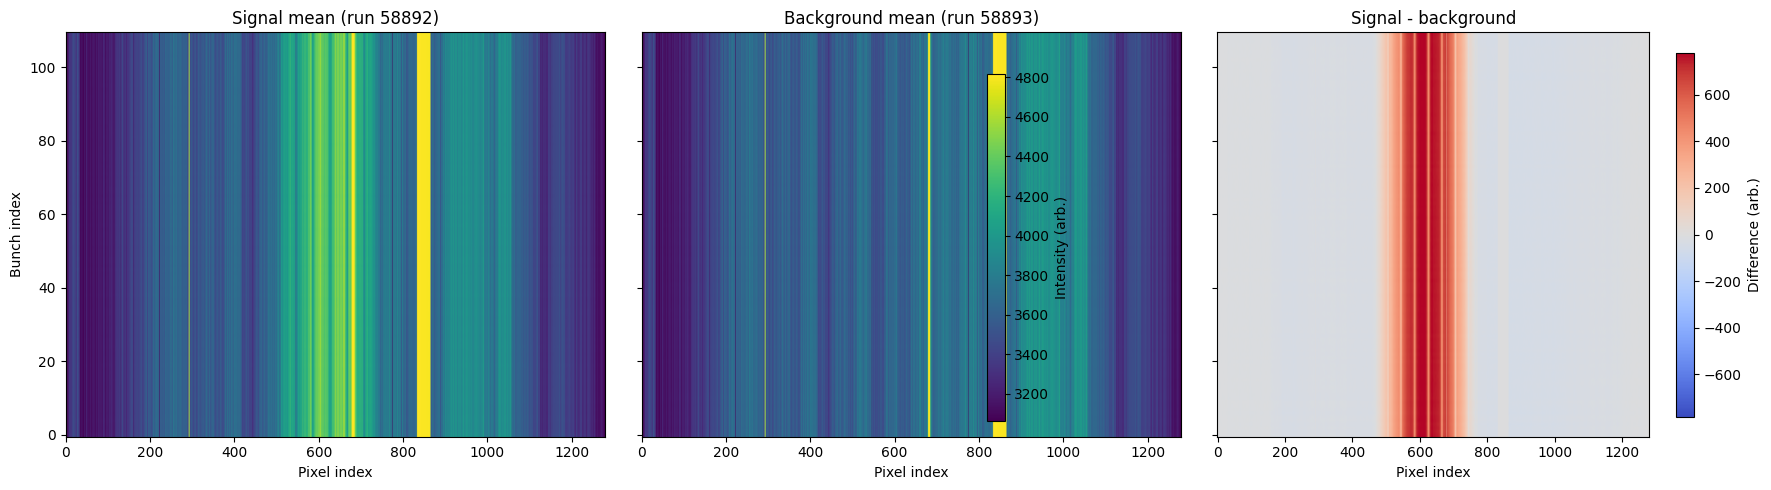

In [9]:
signal_mean = np.nanmean(signal_data.vls, axis=0)
background_mean = np.nanmean(background_data.vls, axis=0)

n_bunches = min(signal_mean.shape[0], background_mean.shape[0])
n_pixels = min(signal_mean.shape[1], background_mean.shape[1])

signal_mean = signal_mean[:n_bunches, :n_pixels]
background_mean = background_mean[:n_bunches, :n_pixels]
diff_image = signal_mean - background_mean

print(f'common mean image shape: {diff_image.shape}')
print(f'diff min / max         : {np.nanmin(diff_image):.3g} / {np.nanmax(diff_image):.3g}')

vmin = np.nanpercentile(np.concatenate([signal_mean.ravel(), background_mean.ravel()]), 1)
vmax = np.nanpercentile(np.concatenate([signal_mean.ravel(), background_mean.ravel()]), 99)
dlim = np.nanpercentile(np.abs(diff_image), 99)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

im0 = axes[0].imshow(signal_mean, aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Signal mean (run {SIGNAL_RUN_NO})')

im1 = axes[1].imshow(background_mean, aspect='auto', origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Background mean (run {BACKGROUND_RUN_NO})')

im2 = axes[2].imshow(diff_image, aspect='auto', origin='lower', cmap='coolwarm', vmin=-dlim, vmax=dlim)
axes[2].set_title('Signal - background')

for ax in axes:
    ax.set_xlabel('Pixel index')
axes[0].set_ylabel('Bunch index')

fig.colorbar(im0, ax=axes[:2], shrink=0.9, label='Intensity (arb.)')
fig.colorbar(im2, ax=axes[2], shrink=0.9, label='Difference (arb.)')
fig.tight_layout()
plt.show()

## Collapse to a 1D Fringe Profile

The shadows are vertical, so after background subtraction we average across the bunch axis to get a single pixel profile. Fringe minima are detected as peaks in the inverted, smoothed profile.

detected shadows         : 3
number of spacings       : 2
median spacing           : 40.50 px
mean spacing             : 40.50 px
std of spacings          : 0.50 px
detector spacing         : 2.0250 mm
object spacing           : 0.6800 mm
magnification            : 2.9779 x


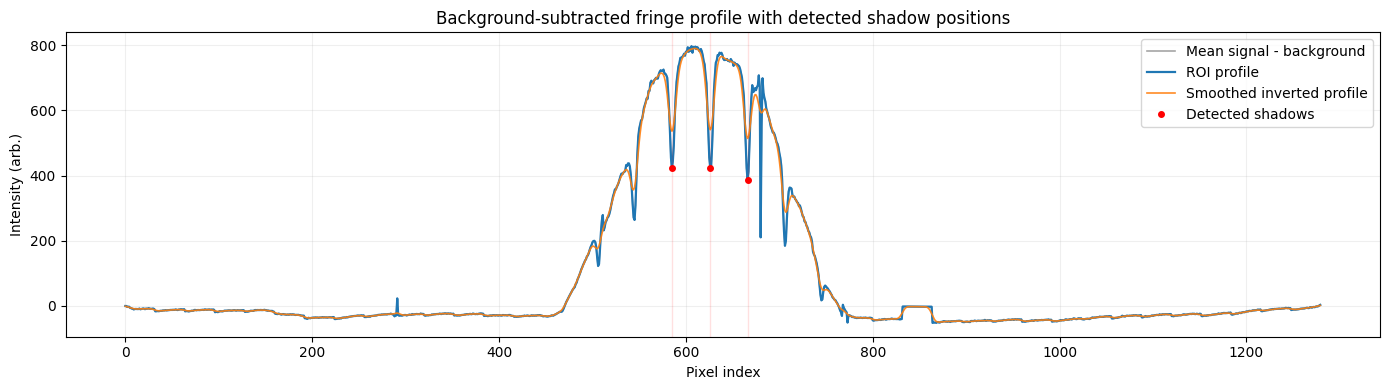

In [10]:
profile = np.nanmean(diff_image, axis=0)
x = np.arange(profile.size)

if PROFILE_ROI is None:
    roi_start, roi_stop = 0, profile.size
else:
    roi_start, roi_stop = PROFILE_ROI
    roi_start = max(0, int(roi_start))
    roi_stop = min(profile.size, int(roi_stop))

x_roi = x[roi_start:roi_stop]
profile_roi = profile[roi_start:roi_stop]
smoothed_dark = gaussian_filter1d(-profile_roi, sigma=SMOOTH_SIGMA_PIXELS, mode='nearest')

if MIN_PEAK_PROMINENCE is None:
    prominence = max(float(np.nanstd(smoothed_dark)) * 0.35, float(np.nanmax(smoothed_dark)) * 0.05)
else:
    prominence = float(MIN_PEAK_PROMINENCE)

peaks, props = find_peaks(
    smoothed_dark,
    distance=MIN_PEAK_DISTANCE_PIXELS,
    prominence=prominence,
)
peak_pixels = x_roi[peaks]
spacings_px = np.diff(peak_pixels)

if peak_pixels.size < 2:
    raise RuntimeError('Could not detect at least two fringes. Adjust PROFILE_ROI or the peak-finding parameters.')

median_spacing_px = float(np.nanmedian(spacings_px))
mean_spacing_px = float(np.nanmean(spacings_px))
std_spacing_px = float(np.nanstd(spacings_px))
spacing_mm = median_spacing_px * PIXEL_SIZE_MM
magnification = spacing_mm / GRID_SPACING_MM

print(f'detected shadows         : {peak_pixels.size}')
print(f'number of spacings       : {spacings_px.size}')
print(f'median spacing           : {median_spacing_px:.2f} px')
print(f'mean spacing             : {mean_spacing_px:.2f} px')
print(f'std of spacings          : {std_spacing_px:.2f} px')
print(f'detector spacing         : {spacing_mm:.4f} mm')
print(f'object spacing           : {GRID_SPACING_MM:.4f} mm')
print(f'magnification            : {magnification:.4f} x')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x, profile, color='0.65', lw=1.2, label='Mean signal - background')
ax.plot(x_roi, profile_roi, color='tab:blue', lw=1.6, label='ROI profile')
ax.plot(x_roi, -smoothed_dark, color='tab:orange', lw=1.2, alpha=0.9, label='Smoothed inverted profile')
ax.plot(peak_pixels, profile_roi[peaks], 'ro', ms=4, label='Detected shadows')
for px in peak_pixels:
    ax.axvline(px, color='red', alpha=0.12, lw=1)
ax.set_xlabel('Pixel index')
ax.set_ylabel('Intensity (arb.)')
ax.set_title('Background-subtracted fringe profile with detected shadow positions')
ax.grid(alpha=0.2)
ax.legend(loc='best')
fig.tight_layout()
plt.show()

## Interpretation

The magnification is computed as

$$
M = \frac{\Delta x_{\rm detector}}{\Delta x_{\rm object}} = \frac{(\Delta p)\, s_{\rm pixel}}{0.68\,\mathrm{mm}}
$$

where $\Delta p$ is the median fringe spacing in pixels and $s_{\rm pixel} = 50\,\mu\mathrm{m} = 0.05\,\mathrm{mm}$.

If the automatic peak detection misses or merges fringes, tighten `PROFILE_ROI` around the cleanest part of the profile and rerun the last cell.

## Final Result

The cells above print the detected fringe positions, the spacing in pixels, the corresponding detector spacing in mm, and the final magnification. The last figure shows the background-subtracted profile with the detected shadows marked in red.
